# 

# Tarea 1

In [390]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## EDA

In [391]:
data = pd.read_csv("exercise_dataset.csv") #Importar dataset

In [392]:
data #Revisar el dataset

,"Activity, Exercise or Sport (1 hour)",130 lb,155 lb,180 lb,205 lb,Calories per kg
0,"Cycling, mountain bike, bmx",502,598,695,791,1.750730
1,"Cycling, <10 mph, leisure bicycling",236,281,327,372,0.823236
2,"Cycling, >20 mph, racing",944,1126,1308,1489,3.294974
3,"Cycling, 10-11.9 mph, light",354,422,490,558,1.234853
4,"Cycling, 12-13.9 mph, moderate",472,563,654,745,1.647825
...,...,...,...,...,...,...
243,General cleaning,207,246,286,326,0.721008
244,"Cleaning, dusting",148,176,204,233,0.515199
245,Taking out trash,177,211,245,279,0.617427
246,"Walking, pushing a wheelchair",236,281,327,372,0.823236


In [393]:
data.isnull().sum() #Revisar valores nulos, si es que hay

Activity, Exercise or Sport (1 hour)    0
130 lb                                  0
155 lb                                  0
180 lb                                  0
205 lb                                  0
Calories per kg                         0
dtype: int64

In [394]:
data.duplicated().sum() #Revisar valores duplicados, si es que hay

np.int64(0)

In [395]:
data.columns

Index(['Activity, Exercise or Sport (1 hour)', '130 lb', '155 lb', '180 lb',
       '205 lb', 'Calories per kg'],
      dtype='object')

Por conveniencia vamos a dejar las columnas con la conversión a KG y la columna 'Activity, Exercise or Sport (1 hour)' como solo Actividad(1h) representando todo

In [396]:
data.columns = ['Actividad(1h)', '~59 kg', '~70 kg', '~81 kg', '~93 kg', 'Cal/Kilo']
data.columns

Index(['Actividad(1h)', '~59 kg', '~70 kg', '~81 kg', '~93 kg', 'Cal/Kilo'], dtype='object')

In [397]:
data.describe() #Descripción del dataset

,~59 kg,~70 kg,~81 kg,~93 kg,Cal/Kilo
count,248.000000,248.000000,248.000000,248.000000,248.000000
mean,389.754032,464.689516,539.685484,614.620968,1.359930
std,194.434028,232.019135,269.430029,306.847470,0.678851
min,89.000000,106.000000,123.000000,140.000000,0.310067
25%,236.000000,281.000000,327.000000,372.000000,0.823236
50%,354.000000,422.000000,490.000000,558.000000,1.234853
75%,472.000000,563.000000,654.000000,745.000000,1.647825
max,1062.000000,1267.000000,1471.000000,1675.000000,3.706591


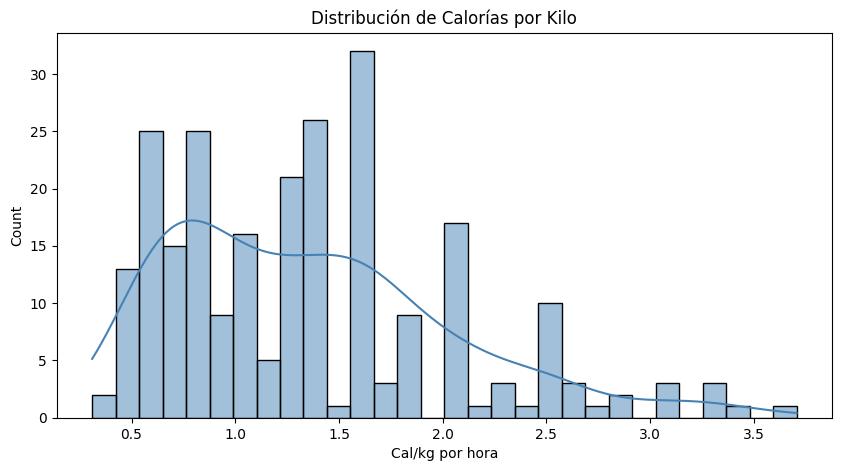

In [398]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Cal/Kilo'], kde=True, bins=30, color='steelblue')
plt.title('Distribución de Calorías por Kilo')
plt.xlabel('Cal/kg por hora')
plt.show()

La distribución nos muestra que el consumo de calorias por kilo en las actividades que el dataset son sumamente bajas, lo cual me hace mucho ruido, y justamente viendo en [Dataset](https://www.kaggle.com/datasets/aadhavvignesh/calories-burned-during-exercise-and-activities?resource=download), se puede ver que en el detalle nos indica que son "Calories per lb" y luego en el dataset descargado nos indica que son "Calories per kg",  por lo tanto es necesario transformar esta columna haciendo la conversión directa de LB a KG.

In [399]:
# Se dividió en vez de multiplicar por 2.2046(1kg = 2.2046 lb), por ello no estaba en kg, sino en lb. Entonces directamente multiplicamos por el doble de 2.2046, y lo convertimos en kg, para que quede en Cal/kg
data['Cal/Kilo'] = data['Cal/Kilo'] * 4.8602

#Verificar
data.head()

,Actividad(1h),~59 kg,~70 kg,~81 kg,~93 kg,Cal/Kilo
0,"Cycling, mountain bike, bmx",502,598,695,791,8.508897
1,"Cycling, <10 mph, leisure bicycling",236,281,327,372,4.001090
2,"Cycling, >20 mph, racing",944,1126,1308,1489,16.014230
3,"Cycling, 10-11.9 mph, light",354,422,490,558,6.001635
4,"Cycling, 12-13.9 mph, moderate",472,563,654,745,8.008760


### Volvemos a ejecutar el mismo histograma con los cambios realizados

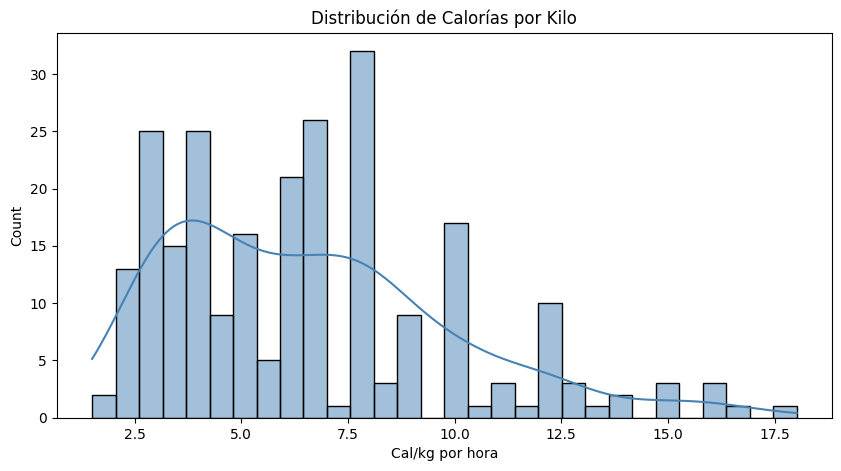

In [400]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Cal/Kilo'], kde=True, bins=30, color='steelblue')
plt.title('Distribución de Calorías por Kilo')
plt.xlabel('Cal/kg por hora')
plt.show()

##### Boxplots

La distribución nos muestra que la gran mayoría de las actividades fisicas presentadas suponen un gasto entre 2.5 y 9 cal/kg por hora siendo el peak en 8 cal/kg, con muy pocos resultados sobre los 15 cal/kg porque estos resultan en actividades de alto rendimiento más pensado en atletas.

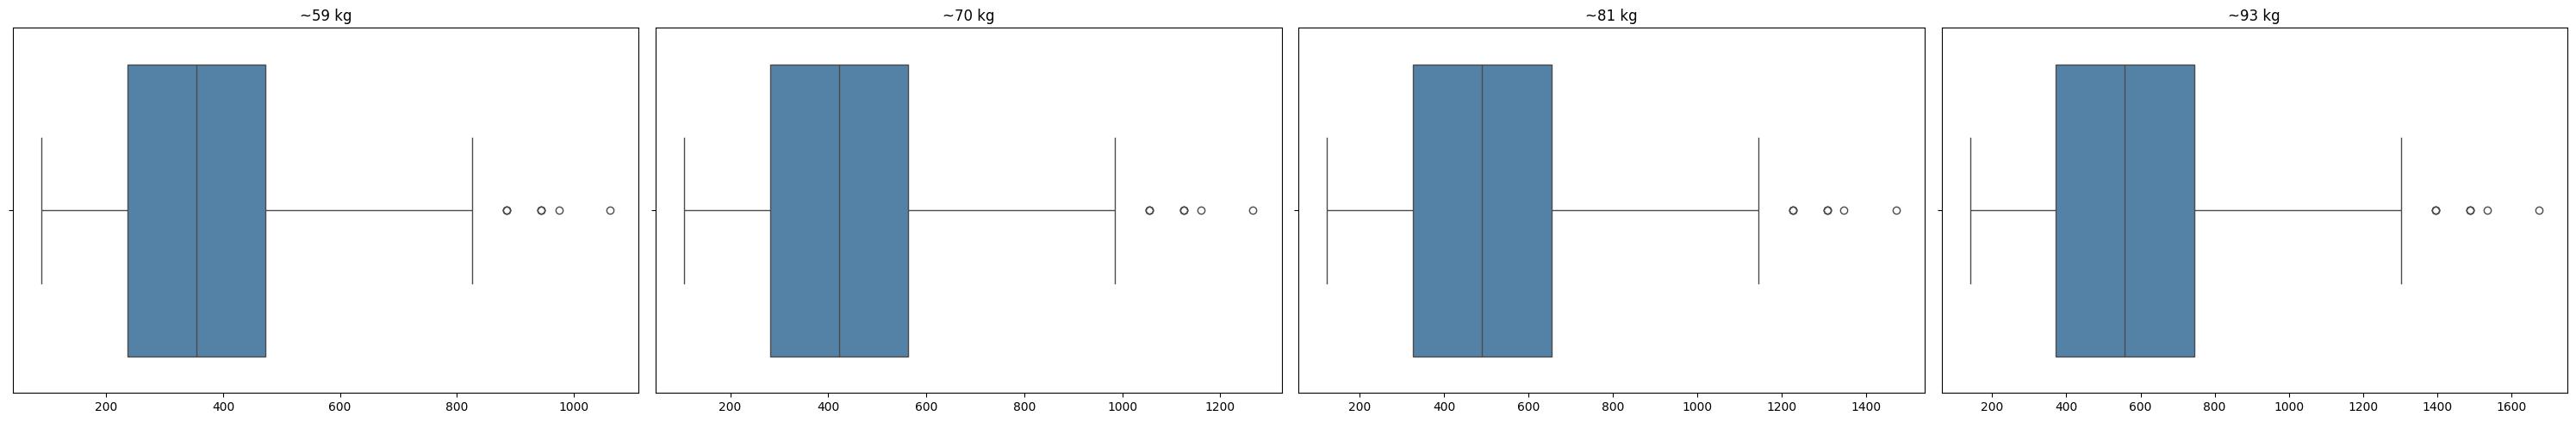

In [401]:
cols = ['~59 kg', '~70 kg', '~81 kg', '~93 kg']
fig, axes = plt.subplots(1, 4, figsize=(30, 5))
for ax, col in zip(axes, cols):
    sns.boxplot(x=data[col], ax=ax, color='steelblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

El análisis visual de estos boxplots puede validar la relación directa que existe entre más mas corporal es un incremento en el gasto energético, siendo más calorías. Por otra parte, el hecho de que todos los rectángulos muestren un tamaño y una proporción similar a la vista se debe por el cálculo de las calorías para cada peso, el cual se deriva proporcionalmente de la columna de cal/kg. Esto provoca que, aunque los valores vayan cambiando según el grupo de peso, la dispersión y distribución se mantengan constantes.

#### Correlación

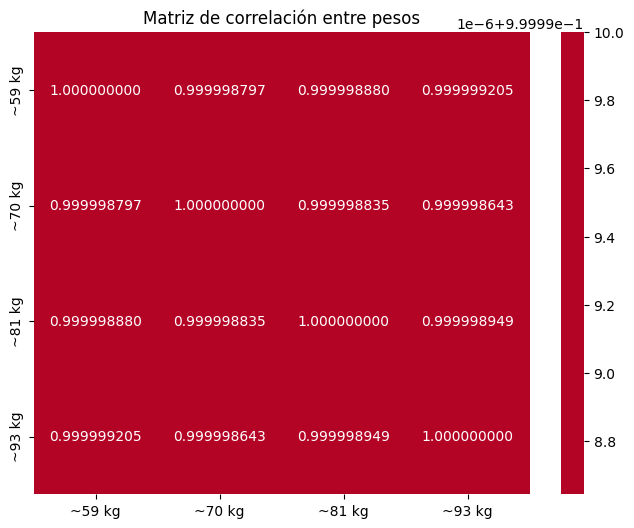

In [402]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[['~59 kg', '~70 kg', '~81 kg', '~93 kg']].corr(),
            annot=True, cmap='coolwarm', center=0, fmt='.9f')
plt.title('Matriz de correlación entre pesos')
plt.show()

##### Scatterplot

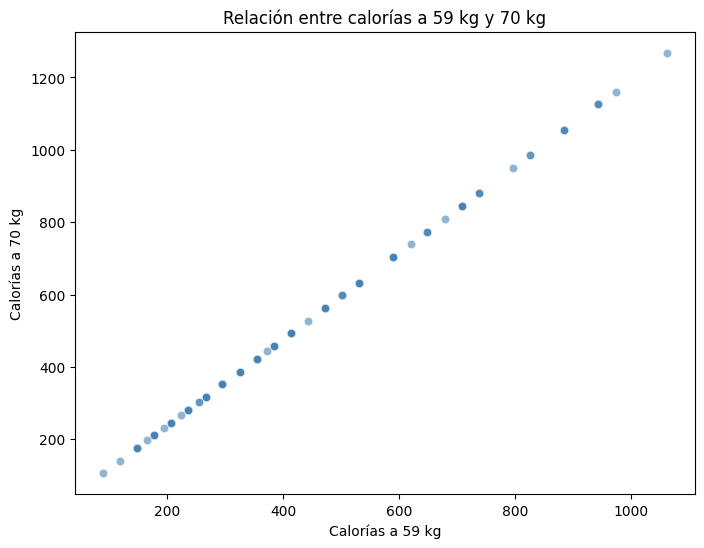

In [403]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='~59 kg', y='~70 kg', alpha=0.6, color='steelblue')
plt.title('Relación entre calorías a 59 kg y 70 kg')
plt.xlabel('Calorías a 59 kg')
plt.ylabel('Calorías a 70 kg')
plt.show()

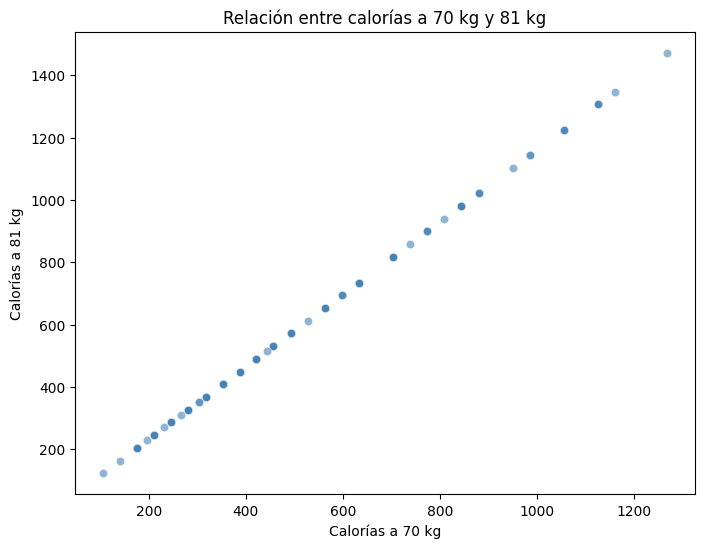

In [404]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='~70 kg', y='~81 kg', alpha=0.6, color='steelblue')
plt.title('Relación entre calorías a 70 kg y 81 kg')
plt.xlabel('Calorías a 70 kg')
plt.ylabel('Calorías a 81 kg')
plt.show()

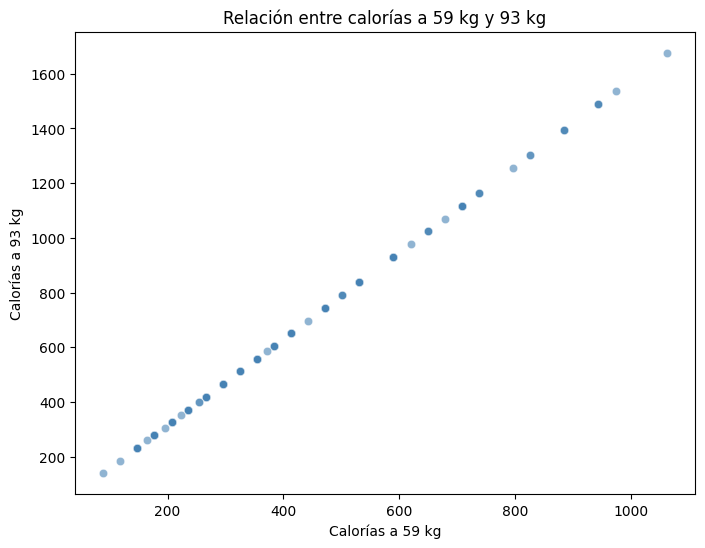

In [405]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='~59 kg', y='~93 kg', alpha=0.6, color='steelblue')
plt.title('Relación entre calorías a 59 kg y 93 kg')
plt.xlabel('Calorías a 59 kg')
plt.ylabel('Calorías a 93 kg')
plt.show()

Se realizaron ScatterPlots con el objetivo de tener visualmente la relación entre las variables de pesos:

 (1) Pesos iniciales(59kg y 70kg)

 (2) Pesos intermedios(70kg y 81kg) 

 (3) Psos en cada extremo(59kg y 93kg)

  En todos los casos anlizados, los puntos se distribuyen sobre una linea recta en pendiente positiva. Este comportamiento es consistente con lo dicho anteriormente, que el gasto calórico es proporcional al peso. Esta relacion lineal observada respalda el uso del modelo de Regresión Lineal como herramienta predictiva, modelos más complejos no aportarian una mejora notable y solo agregarían dificultad.

# Preprocesamiento de Datos

Para lograr entrenar el modelo capaz de predecir el gasto energético para cualquier peso arbitrario y que no se limite por los cuatro valopres que indican las columnas actuales, tenemos que reestructurar el dataset haciendo que se extienda en filas (largo) y no defina con solo las columnas (ancho), pivotando las variables de las columnas para convertirlas en una variable númerica continua en filas. Al hacer este procedimiento el modelo podrá entender la relación lineal y continua que presentan entre la masa corporal, la intensidad y el gasto calórico final.

In [406]:
data_final = data.melt(
    id_vars=['Actividad(1h)'],
    value_vars=['~59 kg', '~70 kg', '~81 kg', '~93 kg'],
    var_name='Peso (kg)',
    value_name='Calorias'
)

In [407]:
data_final.head()

,Actividad(1h),Peso (kg),Calorias
0,"Cycling, mountain bike, bmx",~59 kg,502
1,"Cycling, <10 mph, leisure bicycling",~59 kg,236
2,"Cycling, >20 mph, racing",~59 kg,944
3,"Cycling, 10-11.9 mph, light",~59 kg,354
4,"Cycling, 12-13.9 mph, moderate",~59 kg,472


Nos falta borrar el ~ para que el peso quede en numero, el unico problema que veo con esto es que pierde exactitud el valor final en cierto sentido, asi que asumiré este margen de error a cambio de poder trabajarlo en kg y lograr hacer que el modelo funcione correctamente con valores númericos.

In [408]:
data_final['Peso (kg)'] = data_final['Peso (kg)'].str.replace('~', '').str.replace(' kg', '').astype(int)

In [409]:
data_final

,Actividad(1h),Peso (kg),Calorias
0,"Cycling, mountain bike, bmx",59,502
1,"Cycling, <10 mph, leisure bicycling",59,236
2,"Cycling, >20 mph, racing",59,944
3,"Cycling, 10-11.9 mph, light",59,354
4,"Cycling, 12-13.9 mph, moderate",59,472
...,...,...,...
987,General cleaning,93,326
988,"Cleaning, dusting",93,233
989,Taking out trash,93,279
990,"Walking, pushing a wheelchair",93,372


Quedando ahora sí un total de 992 filas y 3 columnas

In [410]:
X = data_final[['Actividad(1h)', 'Peso (kg)']] #Variables independientes
y = data_final['Calorias'] #Variable dependiente

In [411]:
# Para lograr considerar la columna de actividad como una variable categórica, usamos onehoteconder para transformarla a numerica, y luego el columntransfer para aplicarselo a la columna de actividad
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Actividad(1h)']), # Transformamos la variable a numérica
        ('num', 'passthrough', ['Peso (kg)'])
    ]
)

# Entrenamiento del Modelo

## Regresión Lineal

In [412]:
pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('model', LinearRegression())
  ])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42) #Dividir en entrenamiento y testing

scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

print(f"  R² por fold: {scores}")
print(f"  R² promedio: {scores.mean()}")
print(f"  R² desviación estándar: {scores.std()}")


  R² por fold: [0.90245505 0.83531532 0.88594726 0.87854488 0.83746533]
  R² promedio: 0.8679455680685599
  R² desviación estándar: 0.026911296146171607


In [413]:
pipeline.fit(X_train, y_train) 

y_pred = pipeline.predict(X_test)

In [414]:
pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## ElasticNet

In [415]:
pipe_elastic = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42))
])
pipe_elastic.fit(X_train, y_train)
y_pred_elastic = pipe_elastic.predict(X_test)

In [434]:
pipe_elastic

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Gráficos de Dispersión

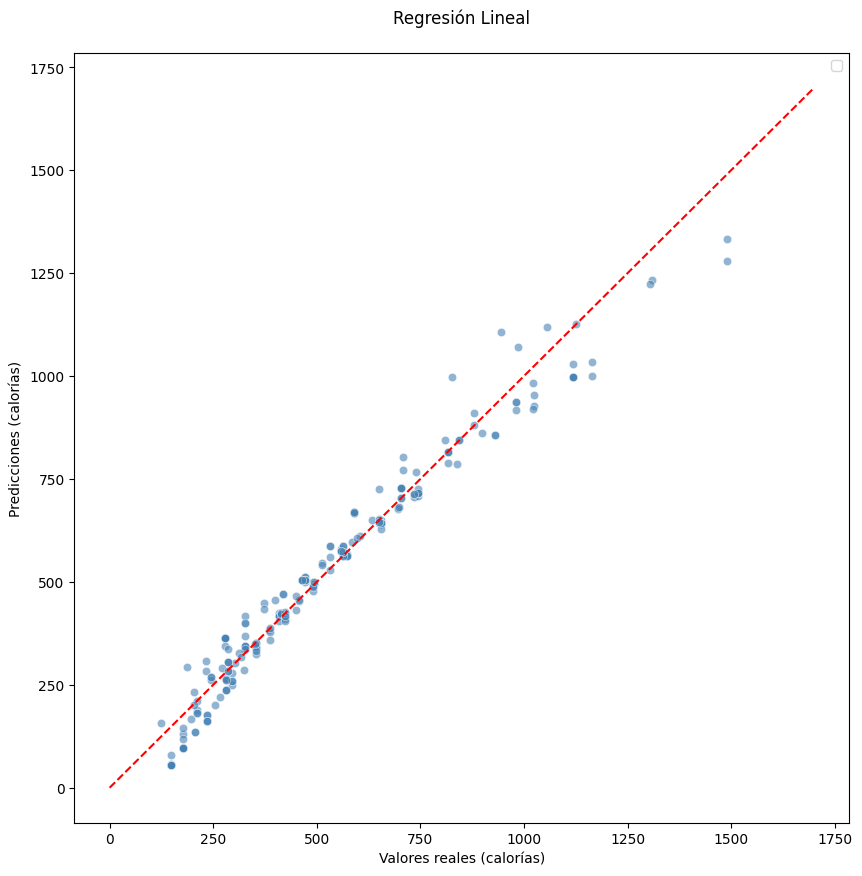

In [437]:
#Gráfico 1: Regresión Lineal

fig, ax = plt.subplots(figsize=(10, 10))
ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='steelblue')
ax.set_xlabel("Valores reales (calorías)")
ax.set_ylabel("Predicciones (calorías)")
ax.set_title(
    f"Regresión Lineal\n"
)
ax.plot([0, 1700], [0, 1700], "--", color="red")
ax.legend([])
plt.show()

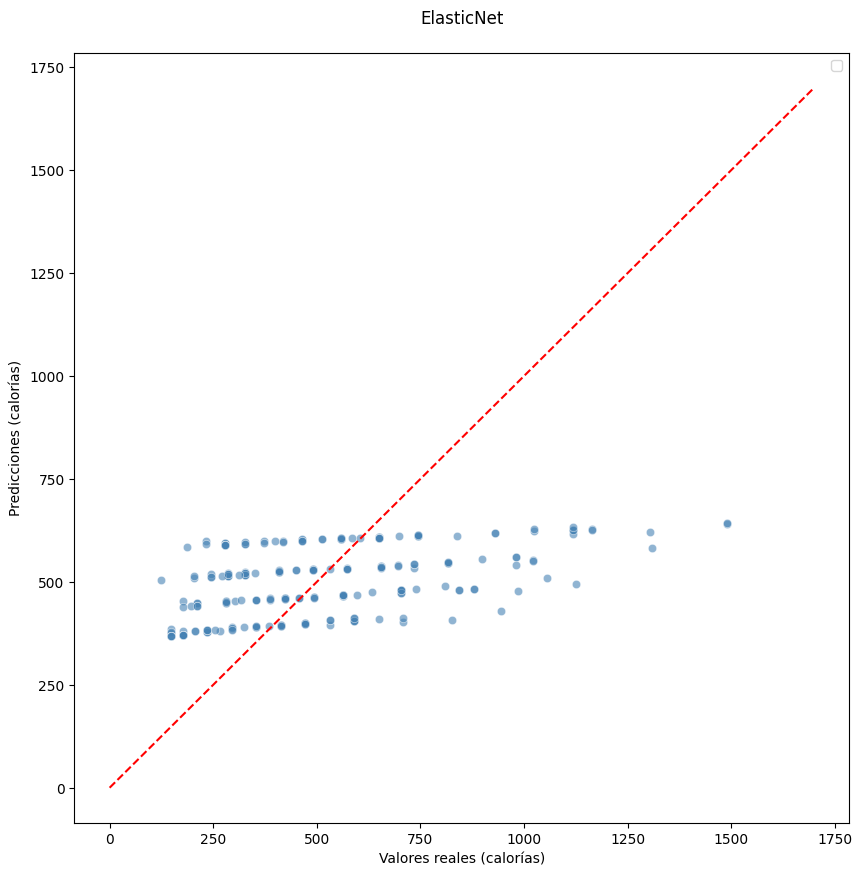

In [438]:
#Gráfico 2: ElasticNet
fig, ax = plt.subplots(figsize=(10, 10))
ax = sns.scatterplot(x=y_test, y=y_pred_elastic, alpha=0.6, color='steelblue')
ax.set_xlabel("Valores reales (calorías)")
ax.set_ylabel("Predicciones (calorías)")
ax.set_title(
    f"ElasticNet\n"
)
ax.plot([0, 1700], [0, 1700], "--", color="red")
ax.legend([])
plt.show()

# Métricas

In [430]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

mse_elastic = mean_squared_error(y_test, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)

In [432]:
print("Regresión Lineal:")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

print("------------------------\n")
print("ElasticNet:")
print(f"MSE:  {mse_elastic:.2f}")
print(f"RMSE: {rmse_elastic:.2f}")
print(f"MAE:  {mae_elastic:.2f}")
print(f"R²:   {r2_elastic:.4f}")


Regresión Lineal:
MSE:  2733.91
RMSE: 52.29
MAE:  37.26
R²:   0.9622
------------------------

ElasticNet:
MSE:  57405.87
RMSE: 239.60
MAE:  187.86
R²:   0.2065


El análisis de las métricas nos revela que la Regresión Lineal presenta un right fit para el conjunto de datos. Con un $R^2$ de 0,9622, el modelo logra explicar el 96,22% de la varianza que existe en los datos. Esto nos confirma lo planteado inicialmente, que la relación lineal entre la masa corporal, la intensidad de la actividad/depore y el gasto calórico total es sólida, solo dejando un margen de 4% que sería nuestro ruido que lo podría interpretar como los outliers de los deportes que tenían un gasto calórico de nivel atleta.

Al comparar este rendimiento con técnicas de regularización como ElasticNet, se obserba una amplia superioridad con el tradicional. La implementación de esta regularización resultó una idea en contra, ya que este empeoró los datos generando un underfitting muy notorio. Esta diferencia se hace aún más notoría al evaluar el MSE de ambos modelos. Dado que esta métrica penaliza severamente los errores, el modelo ElasticNet entregó un valor significativamente alto porque sus predicciones se alejaron fuertemente de lo que era real. En contraste, la Regresión Lineal se mantuvo con un MSE mucho más baj, y esto no es por una falta de penalización, sino porque por su alta precisión evitó que se egeneraran errores grandes. En conclusión, estas métricas con la vista de gráficos de dispersión, nos permite validar que la regresión  lineal es el adecuado para capturar la variabilidad de nuestros datos.

# EXTRA

In [435]:
def calorias(actividad, peso, tiempo):
    entrada = pd.DataFrame({
        'Actividad(1h)': [actividad],
        'Peso (kg)': [peso]
    })
    cal_por_hora = pipeline.predict(entrada)[0]
    cal_total = cal_por_hora * (tiempo / 60)

    print(f"Actividad: {actividad}")
    print(f"Peso: {peso} kg")
    print(f"Tiempo: {tiempo} min")
    print(f"Calorías quemadas: {cal_total:.0f}")
    return cal_total

In [436]:
#Buscar actividad
actividades = data_final['Actividad(1h)'].unique()
buscar = '' 
coincidencias = [a for a in actividades if buscar.lower() in a.lower()]
print(f"Actividades que contienen '{buscar}':")
for act in coincidencias:
    print(f"  - {act}")

Actividades que contienen '':
  - Cycling, mountain bike, bmx
  - Cycling, <10 mph, leisure bicycling
  - Cycling, >20 mph, racing
  - Cycling, 10-11.9 mph, light
  - Cycling, 12-13.9 mph, moderate
  - Cycling, 14-15.9 mph, vigorous
  - Cycling, 16-19 mph, very fast, racing
  - Unicycling
  - Stationary cycling, very light
  - Stationary cycling, light
  - Stationary cycling, moderate
  - Stationary cycling, vigorous
  - Stationary cycling, very vigorous
  - Calisthenics, vigorous, pushups, situps…
  - Calisthenics, light
  - Circuit training, minimal rest
  - Weight lifting, body building, vigorous
  - Weight lifting, light workout
  - Health club exercise
  - Stair machine
  - Rowing machine, light
  - Rowing machine, moderate
  - Rowing machine, vigorous
  - Rowing machine, very vigorous
  - Ski machine
  - Aerobics, low impact
  - Aerobics, high impact
  - Aerobics, step aerobics
  - Aerobics, general
  - Jazzercise
  - Stretching, hatha yoga
  - Mild stretching
  - Instructing aer

In [426]:
#Modo uso: calorias('actividad, peso, tiempo (mins))

calorias('Calisthenics, light', 70, 90)

Actividad: Calisthenics, light
Peso: 70 kg
Tiempo: 90 min
Calorías quemadas: 342


np.float64(341.8742237468081)